In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
    
This code was built using `NumPy: 2.2.5`, `SciPy: 1.15.1`, `SymPy: 1.13.3`.
</div>

In this notebook we will learn how to apply the deflation technique from [[1]](https://arxiv.org/pdf/2407.06834).

[1] Andrés Miniguano-Trujillo, John William Pearson, Benjamin D Goddard (2025). **Efficient nonlocal linear image denoising: Bilevel optimization with Nonequispaced Fast Fourier Transform and matrix-free preconditioning**. Accepted at SIAM journal on Imaging Sciences. arXiv:2407.06834.

In [1]:
# Libraries
import numpy as np
import scipy.sparse as sp

In [2]:
np.set_printoptions(linewidth=180, precision = 2)

# Change of basis

<div class="alert alert-block alert-success">
Consider the hermitian matrix $A \in \mathbb{H}_n(\mathbb{F})$ with an eigenpair $(\lambda,\mathbf{v})$. We can build a deflation $Q \in \mathcal{M}_n(\mathbb{F})$ based on $\mathbf{v}$ such that the matrix $\mathsf{A}_{Q} = Q^{-1} A Q$ has a block-structure that isolates $\lambda$. In what follows, we will explore how to build $Q = Q(\mathbf{v})$, its inverse, their operator forms, and test them against a set of exact and numerical examples.
</div>

## The $v_1 \neq 0$ case

Let us assume that $v_1 \neq 0$ and that $v_1 \in \mathbb{R}$. In the case that $v_1 \in \mathbb{C}$, we can just multiply $\mathbf{v}$ by $\overline{\mathbf{v}}$ and carry on with the next steps. The explicit form of $Q$ is given by the bordered matrix
\begin{align}
Q(\mathbf{v}) =
\begin{bmatrix}
    v_1 & \mathbf{v}_{2:n}^\dagger
    \\
    \mathbf{v}_{2:n} & - v_1 \mathsf{I}_{n-1}
\end{bmatrix}
\end{align}

Let us implement this for any vector $\mathbf{v}$:

In [3]:
rng = np.random.default_rng(seed=2025)

In [4]:
n = 8
# Generate a random eigenvector of size n
𝐯 = rng.uniform(-1,0,n) + 1.j * np.random.uniform(-1, 1, n)
# Correct first entry
𝐯   *= 𝐯[0].conj()
𝐯[0] = 𝐯[0].real
print(𝐯)

[ 0.14+0.j   -0.02-0.23j  0.06-0.06j  0.23-0.06j  0.14-0.01j  0.25-0.34j  0.07-0.25j  0.34-0.02j]


In [5]:
def Q_mat(v):
    n = v.size
    # Main diagonal
    Q = sp.diags(np.broadcast_to(-v[0], (n,)), offsets = 0, shape = (n,n), format = 'dok', dtype = v.dtype)
    # First row
    Q[0] = v.conj()
    # First column
    Q[:,0] = v
    return Q.tocsr()
Q = Q_mat(𝐯)
Q.toarray()

array([[ 0.14+0.j  , -0.02+0.23j,  0.06+0.06j,  0.23+0.06j,  0.14+0.01j,  0.25+0.34j,  0.07+0.25j,  0.34+0.02j],
       [-0.02-0.23j, -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.06-0.06j,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.23-0.06j,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.14-0.01j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.25-0.34j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.07-0.25j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ],
       [ 0.34-0.02j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ]])

The matrix $Q(\mathbf{v})$ is invertible, where
\begin{align*}
    \big[Q(\mathbf{v})\big]^{-1} = \frac{1}{v_1 \|\mathbf{v}\|^2} \mathbf{v} \otimes \mathbf{v}^\dagger - \operatorname{diag}(0, v_1^{-1} \mathbf{1}_{n-1} );
\end{align*}
this is just a weighted correction of a projection. Geometrically, $ (\mathbf{v} \otimes \mathbf{v}^\dagger) \big/ {v_1 \|\mathbf{v}\|^2} $ represents an orthogonal projection onto the direction of $\mathbf{v}$. However, this alone is not enough to fully correct the change of basis induced by $\mathbf{v}$. The diagonal term, $\operatorname{diag}(0, v_1^{-1} \mathbf{1}_{n-1} )$, acts as an anisotropic corrector that restores any information not captured in the projection.

In [6]:
def Q_mat_inv(v):
    n = v.size
    # Projection
    Qi = sp.kron(v[:,np.newaxis]/( v[0] * v.dot(v.conj()).real ), v.conj(), format = 'csr')
    # Anisotropic corrector
    Qi.setdiag( Qi.diagonal() - np.r_[0.0, np.broadcast_to(v[0]**-1, (n-1,))] )
    return Qi
Qi = Q_mat_inv(𝐯)
Qi.toarray()

array([[ 0.26+0.00e+00j, -0.04+4.41e-01j,  0.12+1.22e-01j,  0.44+1.09e-01j,  0.28+1.31e-02j,  0.49+6.51e-01j,  0.13+4.85e-01j,  0.66+4.74e-02j],
       [-0.04-4.41e-01j, -6.63-2.32e-19j,  0.19-2.13e-01j,  0.12-7.61e-01j, -0.02-4.71e-01j,  1.03-9.13e-01j,  0.8 -2.88e-01j, -0.01-1.12e+00j],
       [ 0.12-1.22e-01j,  0.19+2.13e-01j, -7.27-3.96e-18j,  0.25-1.57e-01j,  0.13-1.23e-01j,  0.52+6.22e-02j,  0.28+1.54e-01j,  0.32-2.86e-01j],
       [ 0.44-1.09e-01j,  0.12+7.61e-01j,  0.25+1.57e-01j, -6.59-4.25e-18j,  0.48-9.42e-02j,  1.1 +8.96e-01j,  0.43+7.64e-01j,  1.14-1.96e-01j],
       [ 0.28-1.31e-02j, -0.02+4.71e-01j,  0.13+1.23e-01j,  0.48+9.42e-02j, -7.08+1.14e-18j,  0.55+6.67e-01j,  0.16+5.09e-01j,  0.71+1.74e-02j],
       [ 0.49-6.51e-01j,  1.03+9.13e-01j,  0.52-6.22e-02j,  1.1 -8.96e-01j,  0.55-6.67e-01j, -4.85-8.79e-18j,  1.45+5.77e-01j,  1.35-1.56e+00j],
       [ 0.13-4.85e-01j,  0.8 +2.88e-01j,  0.28-1.54e-01j,  0.43-7.64e-01j,  0.16-5.09e-01j,  1.45-5.77e-01j, -6.42-3.34e-17j,  0.

Let's check that the inverse is exact:

In [7]:
np.allclose(Q.dot(Qi).toarray(), np.eye(n, dtype='complex')), np.allclose(Qi.dot(Q).toarray(), np.eye(n, dtype='complex'))

(True, True)

We notice that $\big[Q(\mathbf{v})\big]^{-1}$ is dense, so it is not practical to construct it explicitly for large values of $n$. However, we can compute its action on any vector since the Kronecker product becomes an inner product. Here:
\begin{align*}
    Q(\mathbf{v})\mathbf{u} = 
    \begin{bmatrix} 
        \langle \mathbf{u}, \mathbf{v}\rangle 
        \\ 
        u_1 \mathbf{v}_{2:n} - v_1 \mathbf{u}_{2:n} 
    \end{bmatrix}
    \qquad\qquad
    \big[Q(\mathbf{v})\big]^{-1}\mathbf{u} = 
    v_1^{-1}
    \left\{
    \frac{ \langle \mathbf{u},\mathbf{v}\rangle }{ \|\mathbf{v}\|^2 } \mathbf{v} -
    \begin{bmatrix} 
        0 
        \\ 
        \mathbf{u}_{2:n} 
    \end{bmatrix}
    \right\}
\end{align*}

In [8]:
def Qv_op(u): 
    return np.r_[np.vdot(v,u), u[0] * v[1:] - v[0] * u[1:]]    # ⟨𝐮,𝐯⟩ = 𝐯^† 𝐮, see documentation of vdot
def Qv_in(u): 
    # Projection
    a = np.vdot(v,u) * v / np.vdot(v,v)
    # Correction
    a[1:] -= u[1:]
    # Scaling
    a /= v[0]
    return a

In [9]:
𝐮 = rng.uniform(0,2,n) + 1.j * np.random.uniform(-2, 2, n)

Let's verify the application:

In [10]:
np.allclose(Qv_in(Qv_op(𝐮)), 𝐮), np.allclose(Qv_op(Qv_in(𝐮)), 𝐮)

(True, True)

In [11]:
np.allclose(Q.dot(𝐮), Qv_op(𝐮)), np.allclose(Qi.dot(𝐮), Qv_in(𝐮))

(True, True)

## The case $v_1=0$

Let $\imath \in [2:n]$ be the first index where $v_i \neq 0$.
There are two paths available for this case: 

**(1)** Apply a permutation $(1,\imath) \in \operatorname{S}_n$, represented by the matrix $P_{(1,\imath)}$, to $A$ and define $B = P^\top A P$. Defining $\mathbf{u} := P^\top \mathbf{v}$, we obtain that 
\begin{align*}
    B\mathbf{u} = P^\top A P P^\top \mathbf{v} = P^\top A \mathbf{v} = P^\top \lambda \mathbf{v} = \lambda P^\top \mathbf{v}.
\end{align*}
As a result, $\mathbf{u}$ is an eigenvector of $B$ with a nonzero first entry. We can then determine $Q(\mathbf{u})$, and 
\begin{align*}
    P\big[Q(\mathbf{u})\big]^{-1} B \,\, Q(\mathbf{u}) P^\top = P\big[Q(\mathbf{u})\big]^{-1} P^\top A P \, Q(\mathbf{u}) P^\top 
    = \big[P Q(\mathbf{u}) P^\top\big]^{-1} A \big[P Q(\mathbf{u}) P^\top\big]
\end{align*}
has a block structure with a singled-out $(\imath,\imath)$ entry. Moreover, notice that $P^2 = \mathsf{I}_n$, so we do not need to define a transpose.

In [12]:
def Permutation(v, i=0):
    n = v.size
    P = sp.eye(n, format = 'dok')
    P[[0, i]] = P[[i, 0]]    # Swap rows 0 and i
    return P.tocsr()
def Pv_op(u, i=0):
    v = u.copy()
    v[0], v[i] = v[i], v[0]
    return v

In [13]:
P = Permutation(v,1)
np.allclose(P.T.dot(P).toarray(), np.eye(n))

True

In [14]:
np.allclose(Permutation(v, 3).dot(𝐮), Pv_op(𝐮,3)), np.allclose( Pv_op(Pv_op(𝐮, 3),3), 𝐮)

(True, True)

**(2)** Alternatively, we can extend the definition of $Q$ and its inverse as follows:
\begin{align}
Q(\mathbf{v},\imath) =
\begin{bmatrix}
    - v_\imath \mathsf{I}_{\imath-1}
    \\
    &v_\imath & \mathbf{v}_{\imath+1:n}^\dagger
    \\
    &\mathbf{v}_{\imath+1:n} & - v_\imath \mathsf{I}_{n-\imath}
\end{bmatrix}
\qquad\qquad
\big[Q(\mathbf{v},\imath)\big]^{-1} = 
    \frac{1}{v_\imath}  \begin{bmatrix}
    -\mathsf{I}_{\imath-1}
    \\
    &
    \frac{1}{ \|\mathbf{v}\|^2} \mathbf{v}_{\imath:n} \otimes \mathbf{v}_{\imath:n}^\dagger - \operatorname{diag}(0, \mathbf{1}_{n-\imath} )
    \end{bmatrix}
    =
    \frac{1}{v_\imath \|\mathbf{v}\|^2} \mathbf{v} \otimes \mathbf{v}^\dagger - \frac{1}{v_\imath} \operatorname{diag}( \mathbf{1}_{n} - e_\imath ).
\end{align}

These can be easily implemented by extending the functionality of our previous implementations:

In [15]:
def Q_mat(v, i = 0):
    n = v.size
    # Main diagonal
    Q = sp.diags(np.broadcast_to(-v[i], (n,)), offsets = 0, shape = (n,n), format = 'dok', dtype = v.dtype)
    # First row
    Q[i] = v.conj()
    # First column
    Q[:,i] = v
    return Q.tocsr()

def Q_mat_inv(v, i = 0):
    n = v.size
    # Projection
    Qi = sp.kron(v[:,np.newaxis]/( v[i] * np.vdot(v,v).real ), v.conj(), format = 'csr')
    # Anisotropic corrector
    d = np.ones(n, dtype=v.dtype);    d[i] = 0.0;    d /= v[i]
    Qi.setdiag( Qi.diagonal() - d )
    return Qi

In [16]:
# Create vector
𝐯 = Pv_op(𝐯, 3);    𝐯[:3] = 0.0;    𝐯

array([0.  +0.j  , 0.  +0.j  , 0.  +0.j  , 0.14+0.j  , 0.14-0.01j, 0.25-0.34j, 0.07-0.25j, 0.34-0.02j])

In [17]:
Q = Q_mat(𝐯,3)
Q.toarray()

array([[-0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.14+0.j  ,  0.14+0.01j,  0.25+0.34j,  0.07+0.25j,  0.34+0.02j],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.14-0.01j, -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.25-0.34j,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.07-0.25j,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.34-0.02j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.14+0.j  ]])

In [18]:
Qi = Q_mat_inv(𝐯,3)
Qi.toarray()

array([[-7.38+0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j],
       [ 0.  +0.00e+00j, -7.38+0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j],
       [ 0.  +0.00e+00j,  0.  +0.00e+00j, -7.38+0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j],
       [ 0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.34+0.00e+00j,  0.36+1.68e-02j,  0.63+8.38e-01j,  0.17+6.25e-01j,  0.85+6.10e-02j],
       [ 0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.36-1.68e-02j, -7.  -1.57e-18j,  0.71+8.59e-01j,  0.21+6.55e-01j,  0.91+2.24e-02j],
       [ 0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.63-8.38e-01j,  0.71-8.59e-01j, -4.13-2.31e-16j,  1.87+7.43e-01j,  1.74-2.00e+00j],
       [ 0.  +0.00e+00j,  0.  +0.00e+00j,  0.  +0.00e+00j,  0.17-6.25e-01j,  0.21-6.55e-01j,  1.87-7.43e-01j, -6.14+3.93e-17j,  0.

Again the inverse is exact:

In [19]:
np.allclose(Q.dot(Qi).toarray(), np.eye(n, dtype='complex')), np.allclose(Qi.dot(Q).toarray(), np.eye(n, dtype='complex'))

(True, True)

Similarly, the matrix-free version of the operator can be quickly determined:

\begin{align*}
    Q(\mathbf{v},\imath)\mathbf{u} = 
    \begin{bmatrix} 
        -v_\imath \mathbf{u}_{1:\imath-1}
        \\
        \langle \mathbf{u}, \mathbf{v}\rangle 
        \\ 
        u_\imath \mathbf{v}_{\imath+1:n} - v_\imath \mathbf{u}_{\imath+1:n} 
    \end{bmatrix}
    \qquad\qquad
    \big[Q(\mathbf{v},\imath)\big]^{-1}\mathbf{u} = 
    v_\imath^{-1}
    \left\{
    \frac{ \langle \mathbf{u},\mathbf{v}\rangle }{ \|\mathbf{v}\|^2 } \mathbf{v} -
    \begin{bmatrix} 
        \mathbf{u}_{1:\imath-1} 
        \\
        0 
        \\ 
        \mathbf{u}_{\imath+1:n} 
    \end{bmatrix}
    \right\}
\end{align*}

In [20]:
def Qv_op(u, i=0): 
    #return np.r_[-v[i] * u[:i-1], np.vdot(v,u), u[i] * v[i+1:] - v[i] * u[i+1:]]    # ⟨𝐮,𝐯⟩ = 𝐯^† 𝐮, see documentation of vdot
    a = -v[i] * u;    a[i] = np.vdot(v,u);    a[i+1:] += u[i] * v[i+1:]
    return a
def Qv_in(u, i=0): 
    # Projection
    a = np.vdot(v,u) * v / np.vdot(v,v)
    # Correction
    a[:i]   -= u[:i]
    a[i+1:] -= u[i+1:]
    # Scaling
    a /= v[i]
    return a

In [21]:
np.allclose(Qv_op(Qv_in(u, 3),3), u), np.allclose(Qv_in(Qv_op(u, 3),3), u)

(True, True)

---

# Examples

## Exact

In [22]:
from sympy import Matrix, diag, Rational

Let us showcase the technique for an exact matrix:

In [23]:
A = Matrix( [[1,2,0], [2,0,1], [0,1,1]] );    A

Matrix([
[1, 2, 0],
[2, 0, 1],
[0, 1, 1]])

In [24]:
# Find eigenvectors and associated eigenvalues:
A_eigs = list(A.eigenvals().keys())
print(A_eigs)
[a.evalf() for a in A_eigs]

[1, 1/2 - sqrt(21)/2, 1/2 + sqrt(21)/2]


[1.00000000000000, -1.79128784747792, 2.79128784747792]

In [25]:
print('The eigenvector associated with', A.eigenvects()[0][0], 'is')
𝐯 = A.eigenvects()[0][2][0]
𝐯

The eigenvector associated with 1 is


Matrix([
[-1/2],
[   0],
[   1]])

We can build $Q(\mathbf{v})$ explicitly:

In [26]:
Q = Matrix([[-Rational(1,2),0,1], [0,Rational(1,2),0], [1,0,Rational(1,2)]])
Q

Matrix([
[-1/2,   0,   1],
[   0, 1/2,   0],
[   1,   0, 1/2]])

It's conjugation by $A$ yields a block structure:

In [27]:
Q.inv() * A * Q 

Matrix([
[1, 0, 0],
[0, 0, 5],
[0, 1, 1]])

We can further check that the symbolic inverse coincides with the inverse we have derived:

In [28]:
(((𝐯.norm()**2) * 𝐯[0])**-1  * 𝐯 * 𝐯.H ) - diag([0,1,1], unpack=True)/𝐯[0]   -  Q.inv()

Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

---

## Numeric

In [29]:
import matplotlib.pyplot as plt

Let's build two examples for $n=20$. We will obtain two eigenvectors and partially diagonalise $A$:

In [30]:
rng = np.random.default_rng(seed=2025)

In [31]:
n = 20
A = rng.normal(0.0, 10, (n,n))
A = np.tril(A) + np.tril(A, -1).T    # Guarantee all entries are normal 𝐍(0,10)
A

array([[-22.21, -16.81,   5.67,   3.51,  18.47, -10.77,  -3.9 ,  11.78,   2.58,  -3.87,   7.21,  15.14,  15.99,  12.97,   6.03,   3.48,  -0.38,  15.08,  14.73,  -1.61],
       [-16.81,  -4.  ,   4.84,  -2.59,   6.59,  18.27,   8.82,  -2.78,   3.24,   3.32,   3.03,  -5.93,  16.53,   8.31,   0.97,   1.32,  -4.4 ,  -4.8 ,   3.12,  30.34],
       [  5.67,   4.84,  10.82,   1.55,   8.9 ,  -0.03,  17.85, -17.61, -10.32,  -0.74,  10.39,  -4.76,   2.47,   1.18,   1.87,   4.27,  -8.14,  -9.69,  -3.02, -13.36],
       [  3.51,  -2.59,   1.55,  15.53, -17.33, -10.61,   4.74,   1.9 ,   5.95,   0.26,  32.32,  -8.46, -11.41,   5.77,  12.9 ,   7.7 ,  -1.94,   3.88,  11.51,  21.57],
       [ 18.47,   6.59,   8.9 , -17.33,   6.1 ,   7.16,  15.65,  -8.97, -10.49,   5.68,  -9.35,  -2.25,   1.74, -10.89,  -9.59,   7.25,   5.43,  -8.87, -17.48,   4.51],
       [-10.77,  18.27,  -0.03, -10.61,   7.16,  -2.32,   9.93, -17.57, -13.89,  15.27,  -5.07,   5.64, -14.97,  -0.46,  12.94,   9.45,   0.4 ,  10.67,  -6

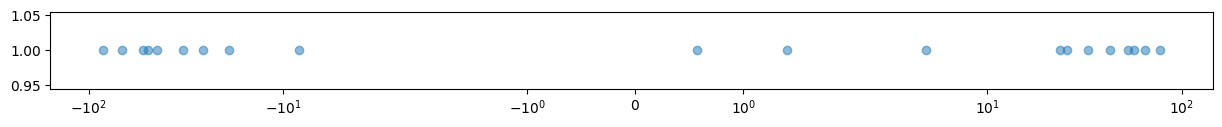

In [32]:
Λ = np.linalg.eigvalsh(A)
plt.figure(figsize=(15,1));    plt.plot( Λ, np.ones(n), 'o', alpha = 0.5 );    plt.xscale('symlog');    plt.show()

In [33]:
print('By removing the smallest eigenvalue, we can improve the condition number from {0:.2f} to {1:.2f}.'.format(abs(Λ).max()/abs(Λ).min(), abs(Λ).max()/np.sort(abs(Λ))[1]))

By removing the smallest eigenvalue, we can improve the condition number from 146.62 to 59.77.


Instead of computing all the eigenvectors, we can just use a Lanczos iteration to determine the vectors associated with the two smallest eigenvalues (in magnitude):

In [34]:
# Check documentation https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html
%timeit -n 40 -r 20 sp.linalg.eigsh(A, k=2, which='SM')
%timeit -n 40 -r 20 sp.linalg.eigsh(A, 2, sigma=0, which='LM')

156 µs ± 30.5 µs per loop (mean ± std. dev. of 20 runs, 40 loops each)
203 µs ± 24.5 µs per loop (mean ± std. dev. of 20 runs, 40 loops each)


In [35]:
Λ_partial, 𝐕 = sp.linalg.eigsh(A, 2, sigma=0, which='LM')

In [36]:
Λ_partial

array([0.57, 1.41])

Let us build $Q(\mathbf{v}^{(1)})$ and the conjugation $B = \big[ Q(\mathbf{v}^{(1)}) \big]^{-1} A Q(\mathbf{v}^{(1)})$

In [37]:
𝐯 = 𝐕.T[0]
𝐯

array([-0.3 ,  0.02,  0.18, -0.19, -0.36, -0.15,  0.05, -0.11,  0.1 , -0.01, -0.19, -0.2 , -0.02, -0.07, -0.44,  0.49, -0.18,  0.06,  0.32, -0.12])

In [38]:
Q = Q_mat(𝐯,0);    Qi = Q_mat_inv(𝐯,0)
np.allclose(np.eye(n), Qi.dot(Q).toarray())

True

In [39]:
B = Qi.dot(A).dot(Q.toarray())
abs(B[0,0] - Λ_partial[0])    # Eigenvalue error at machine precision

np.float64(9.992007221626409e-16)

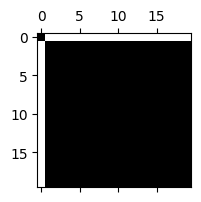

In [40]:
plt.figure(figsize=(2,2));    plt.spy(np.around(B, 10));    plt.show()

We can compute the action of $B$ in a matrix-free fashion as well to avoid storing $Q$ and its inverse: 

In [41]:
def Qv_op(u, v, i=0):
    '''
        Computes Q(v,i)u = a
        ===============================================================
        Inputs:
        u:    array (numeric) of size (n,)
        v:    array (numeric) of size (n,)
        i:    int in [0,n-1] is the index where v≠0 for the first time
        Output:
        a:    array (numeric) of size (n,)
    '''
    a = -v[i] * u;    a[i] = np.vdot(v,u);    a[i+1:] += u[i] * v[i+1:]
    return a
def Qv_in(u, v, i=0):
    '''
        Computes the solution of Q(v,i)] a = u
        ===============================================================
        Inputs:
        u:    array (numeric) of size (n,)
        v:    array (numeric) of size (n,)
        i:    int in [0,n-1] is the index where v≠0 for the first time
        Output:
        a:    array (numeric) of size (n,)
    '''
    # Projection
    a = np.vdot(v,u) * v / np.vdot(v,v)
    # Correction
    a[:i]   -= u[:i]
    a[i+1:] -= u[i+1:]
    # Scaling
    a /= v[i]
    return a

In [42]:
𝐮 = rng.uniform(-1,5,n)

In [43]:
a = Qv_in( A.dot( Qv_op(𝐮, 𝐯, i=0)), 𝐯, i=0)
np.allclose(a, B.dot(𝐮))

True

If we want to improve the precision of the first entry, we can even discard the output of the transformation and use the eigenvalue directly:

In [44]:
abs(Λ_partial[0] * 𝐮[0] - a[0])

np.float64(1.4988010832439613e-14)

A curious effect of the conjugation is that, at least in this case, the condition number of $S=B_{2:n,2:n}$ is reduced:

In [45]:
print('cond(A) = {0:.2f}, cond(S) = {1:.2f}'.format(np.linalg.cond(A), np.linalg.cond(B[1:,1:])))

cond(A) = 146.62, cond(S) = 120.12


At this point, let us also conjugate by the action of the second eigenvector. We know that $A\mathbf{v}^{(2)} = \lambda^{(2)} \mathbf{v}^{(2)}$. As a result, we have that 
\begin{align*}
    \big[ Q(\mathbf{v}^{(1)},1) \big]^{-1} A Q(\mathbf{v}^{(1)},1) \Big[ \big[ Q(\mathbf{v}^{(1)},1) \big]^{-1} \mathbf{v}^{(2)} \Big] 
    = 
    \big[ Q(\mathbf{v}^{(1)},1) \big]^{-1} A \mathbf{v}^{(2)}  
    =
    \big[ Q(\mathbf{v}^{(1)},1) \big]^{-1} \lambda^{(2)}   \mathbf{v}^{(2)}  
    =
    \lambda^{(2)}  \big[ Q(\mathbf{v}^{(1)},1) \big]^{-1} \mathbf{v}^{(2)}.
\end{align*}
Hence we can use the eigeninformation of $\mathbf{v}^{(1)}$ to project $\mathbf{v}^{(2)}$ into the new basis such that it remains an eigenvector. Moreover, since $\mathbf{v}^{(1)}$ has a nonzero first entry, then we know that $\mathbf{v}^{(2)}_* := \big[ Q(\mathbf{v}^{(1)},1) \big]^{-1} \mathbf{v}^{(2)}$ must have a zero first entry due to spectral orthogonality.

In [46]:
𝐯_1 = 𝐕.T[0]
𝐯_2 = Qv_in(𝐕.T[1], 𝐯_1, i=0);    print(𝐯_2);    𝐯_2[0] = 0.0    # Correct floating point error

[-3.12e-17 -3.01e-01  1.60e-01 -2.69e-01  8.15e-01 -7.08e-01 -2.05e+00 -3.76e-01 -1.32e+00  3.80e-01  7.72e-01 -3.90e-01 -2.99e-01 -8.82e-02 -1.11e+00 -2.41e-01 -7.38e-01
 -6.81e-01 -8.38e-02  6.86e-01]


In [47]:
np.linalg.norm(B.dot(𝐯_2)/Λ_partial[1] - 𝐯_2)

np.float64(3.2748000866955566e-14)

Then we can build $C = \big[ Q(\mathbf{v}^{(2)}_*,2) \big]^{-1} B \, \, Q(\mathbf{v}^{(2)}_*,2) = \big[ Q(\mathbf{v}^{(1)},1) Q(\mathbf{v}^{(2)}_*,2) \big]^{-1} A \, \, Q(\mathbf{v}^{(1)},1) Q(\mathbf{v}^{(2)}_*,2)$:

In [48]:
Q_2 = Q_mat(𝐯_2, 2 -1);    Qi_2 = Q_mat_inv(𝐯_2, 2 -1)

In [49]:
Qi_2

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 362 stored elements and shape (20, 20)>

[9.99e-16 1.78e-15]


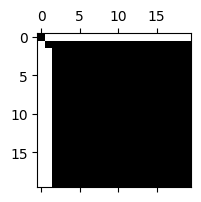

In [50]:
C = Qi_2.dot(B).dot(Q_2.toarray())
print( abs(C.diagonal()[:2] - Λ_partial) )    # Eigenvalue error at machine precision
plt.figure(figsize=(2,2));    plt.spy(np.around(C, 10));    plt.show()

Notice that since $B$ is not symmetric, we cannot claim that $C$ will have a full 2-diagonal block and $C_{2,3:n}$ can be nonzero as depicted.

At last, we can also compute the action of $C$ without storing anything else than $A$ and its two eigenvectors:

In [51]:
𝐮 = rng.uniform(-1,5,n)

In [52]:
# Three step product:
b = Qv_op( Qv_op(𝐮, 𝐯_2, i=1), v_1, i=0)    # Change of basis
b = A.dot(b)                                # Dense operator
b = Qv_in( Qv_in(b, 𝐯_1, i=0), 𝐯_2, i=1)    # Project back to basis
b[0] = 𝐮[0] * Λ_partial[0]

# Compare
np.allclose(b, C.dot(𝐮))

True

To finish, let us compute the condition number of the deflated block:

In [53]:
print('cond(A) = {0:.2f}, cond(S_1) = {1:.2f}, cond(S_2) = {2:.2f}'.format(np.linalg.cond(A), np.linalg.cond(B[1:,1:]), np.linalg.cond(C[2:,2:]) ))

cond(A) = 146.62, cond(S_1) = 120.12, cond(S_2) = 314.07


We cannot guarantee that the block has an improved condition number since we have only removed an eigenvalue, not a singular value. However, for unitary transformations, we can actually assert that the condition number must decrease. This is the objective of the next tutorial.

---